# NetVLAD indoor VPR experiment

Runs one or both official pretrained ResNet-18-conv4 + NetVLAD variants and streams similarities to separate CSV files. The available variants differ by their training dataset: Pitts30k or MSLS.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

# Reload this module so notebook reruns pick up local NetVLAD implementation changes.
import importlib
import indoor_vpr.algorithms.netvlad as netvlad_module
importlib.reload(netvlad_module)

from indoor_vpr import DatasetConfig, ImageDataset, create_algorithm, list_algorithms, stream_vpr_similarity_csv

print('Algorithms:', list_algorithms())

Algorithms: ['anyloc', 'cosplace', 'dinov2', 'mixvpr', 'netvlad', 'rgb_histogram']


## Configuration

In [2]:
# Dataset: change these two folders for a new experiment.
DATASET_ROOT = PROJECT_ROOT / 'datasets' / 'dataset-2'
DATABASE_DIR = DATASET_ROOT / 'frames-IMG_3609'
QUERY_DIR = DATASET_ROOT / 'frames-IMG_3610'
MAX_DATABASE_IMAGES = None
MAX_QUERY_IMAGES = None

# All official NetVLAD backbones and training-dataset checkpoints supported by this project.
# CCT-384 uses a 384x384 square input; the CNN variants use 480x640.
NETVLAD_BACKBONES = {
    'vgg16': {'display_name': 'VGG16', 'image_size': (480, 640), 'descriptor_dim': 32768},
    'resnet18conv4': {'display_name': 'ResNet18-conv4', 'image_size': (480, 640), 'descriptor_dim': 16384},
    'resnet50conv4': {'display_name': 'ResNet50-conv4', 'image_size': (480, 640), 'descriptor_dim': 65536},
    'resnet101conv4': {'display_name': 'ResNet101-conv4', 'image_size': (480, 640), 'descriptor_dim': 65536},
    'cct384': {'display_name': 'CCT-384', 'image_size': (384, 384), 'descriptor_dim': 24576},
}
TRAINING_DATASETS = ('pitts30k', 'msls')
BATCH_SIZE = 8  # Lower this if the larger ResNet models exceed GPU/MPS memory.
NETVLAD_CONFIGURATIONS = {
    f'{backbone}_{trained_on}': {**details, 'backbone': backbone, 'trained_on': trained_on, 'batch_size': BATCH_SIZE}
    for backbone, details in NETVLAD_BACKBONES.items()
    for trained_on in TRAINING_DATASETS
}

# Select one variant, or use list(NETVLAD_CONFIGURATIONS) to run both.
# Running both creates two separate CSV files and takes approximately twice as long.
SELECTED_CONFIGURATIONS = list(NETVLAD_CONFIGURATIONS)  # All 10 official variants

unknown = set(SELECTED_CONFIGURATIONS) - set(NETVLAD_CONFIGURATIONS)
if unknown:
    raise ValueError(f'Unknown NetVLAD configuration(s): {sorted(unknown)}')
if not SELECTED_CONFIGURATIONS:
    raise ValueError('Select at least one NetVLAD configuration.')

ALGORITHM = 'netvlad'
TOP_K = 5
SIMILARITY_CSV_PATHS = {
    name: PROJECT_ROOT / 'outputs' / 'netvlad' / f'_netvlad_{name}_similarity.csv'
    for name in SELECTED_CONFIGURATIONS
}

for name in SELECTED_CONFIGURATIONS:
    config = NETVLAD_CONFIGURATIONS[name]
    print(f"{name}: {config['display_name']} | trained on {config['trained_on']} | {config['descriptor_dim']:,}-D | input {config['image_size'][0]}x{config['image_size'][1]} | batch {config['batch_size']}")

vgg16_pitts30k: VGG16 | trained on pitts30k | 32,768-D | input 480x640 | batch 8
vgg16_msls: VGG16 | trained on msls | 32,768-D | input 480x640 | batch 8
resnet18conv4_pitts30k: ResNet18-conv4 | trained on pitts30k | 16,384-D | input 480x640 | batch 8
resnet18conv4_msls: ResNet18-conv4 | trained on msls | 16,384-D | input 480x640 | batch 8
resnet50conv4_pitts30k: ResNet50-conv4 | trained on pitts30k | 65,536-D | input 480x640 | batch 8
resnet50conv4_msls: ResNet50-conv4 | trained on msls | 65,536-D | input 480x640 | batch 8
resnet101conv4_pitts30k: ResNet101-conv4 | trained on pitts30k | 65,536-D | input 480x640 | batch 8
resnet101conv4_msls: ResNet101-conv4 | trained on msls | 65,536-D | input 480x640 | batch 8
cct384_pitts30k: CCT-384 | trained on pitts30k | 24,576-D | input 384x384 | batch 8
cct384_msls: CCT-384 | trained on msls | 24,576-D | input 384x384 | batch 8


## Load the selected dataset

In [3]:
dataset = ImageDataset.from_config(DatasetConfig(
    database_dir=DATABASE_DIR,
    query_dir=QUERY_DIR,
    max_database_images=MAX_DATABASE_IMAGES,
    max_query_images=MAX_QUERY_IMAGES,
))
print(dataset.summary())

Database: 9318 images | Queries: 4284 images


## Run retrieval

The first run downloads each selected official checkpoint. NetVLAD emits a 16,384-value descriptor per image.

In [ ]:
for config_name in SELECTED_CONFIGURATIONS:
    config = NETVLAD_CONFIGURATIONS[config_name]
    algorithm_options = {
        'backbone': config['backbone'],
        'trained_on': config['trained_on'],
        'image_size': config['image_size'],
        'batch_size': config['batch_size'],
    }
    algorithm = create_algorithm(ALGORITHM, **algorithm_options)
    csv_path = SIMILARITY_CSV_PATHS[config_name]

    print(f'\nRunning {algorithm.name}: {config_name} ({config["display_name"]}, trained on {config["trained_on"]})')
    results = stream_vpr_similarity_csv(
        dataset, algorithm, csv_path=csv_path, progress_every=500, top_k=TOP_K,
    )
    print(f'Done: {results.similarity.shape[0]} queries x {results.similarity.shape[1]} database images')
    print(f'Similarity CSV saved to: {csv_path}')

100%|██████████| 56.4M/56.4M [04:03<00:00, 242kB/s] 


Running netvlad: vgg16_pitts30k (VGG16, trained on pitts30k)
Encoding database descriptors...


Encoded 9318/9318 database images.
Encoding queries and streaming similarity rows...
Wrote 500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_vgg16_pitts30k_similarity.csv
Wrote 1000/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_vgg16_pitts30k_similarity.csv
Wrote 1500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_vgg16_pitts30k_similarity.csv
Wrote 2000/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_vgg16_pitts30k_similarity.csv
Wrote 2500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_vgg16_pitts30k_similarity.csv
Wrote 3000/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_vgg16_pitts30k_similarity.csv
Wrote 3500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_vgg16_pitts30k_similarity.csv
Wrote 4000/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_ne

100%|██████████| 56.4M/56.4M [01:13<00:00, 804kB/s]



Running netvlad: vgg16_msls (VGG16, trained on msls)
Encoding database descriptors...
Encoded 9318/9318 database images.
Encoding queries and streaming similarity rows...
Wrote 500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_vgg16_msls_similarity.csv
Wrote 1000/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_vgg16_msls_similarity.csv
Wrote 1500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_vgg16_msls_similarity.csv
Wrote 2000/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_vgg16_msls_similarity.csv
Wrote 2500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_vgg16_msls_similarity.csv
Wrote 3000/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_vgg16_msls_similarity.csv
Wrote 3500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_vgg16_msls_similarity.csv
Wrote 4000/4284 query ro

...


Running netvlad: resnet50conv4_msls (ResNet50-conv4, trained on msls)
Encoding database descriptors...
Encoded 9318/9318 database images.
Encoding queries and streaming similarity rows...
Wrote 500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_resnet50conv4_msls_similarity.csv
Wrote 1000/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_resnet50conv4_msls_similarity.csv
Wrote 1500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_resnet50conv4_msls_similarity.csv
Wrote 2000/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_resnet50conv4_msls_similarity.csv
Wrote 2500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_resnet50conv4_msls_similarity.csv
Wrote 3000/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_resnet50conv4_msls_similarity.csv
Wrote 3500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/ne

100%|██████████| 106M/106M [02:51<00:00, 650kB/s] 



Running netvlad: resnet101conv4_pitts30k (ResNet101-conv4, trained on pitts30k)
Encoding database descriptors...
Encoded 9318/9318 database images.
Encoding queries and streaming similarity rows...
Wrote 500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_resnet101conv4_pitts30k_similarity.csv
Wrote 1000/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_resnet101conv4_pitts30k_similarity.csv
Wrote 1500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_resnet101conv4_pitts30k_similarity.csv
Wrote 2000/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_resnet101conv4_pitts30k_similarity.csv
Wrote 2500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_resnet101conv4_pitts30k_similarity.csv
Wrote 3000/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_resnet101conv4_pitts30k_similarity.csv
Wrote 3500/4284 query rows to /Use

100%|██████████| 106M/106M [02:57<00:00, 626kB/s] 



Running netvlad: resnet101conv4_msls (ResNet101-conv4, trained on msls)
Encoding database descriptors...
Encoded 9318/9318 database images.
Encoding queries and streaming similarity rows...
Wrote 500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_resnet101conv4_msls_similarity.csv
Wrote 1000/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_resnet101conv4_msls_similarity.csv
Wrote 1500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_resnet101conv4_msls_similarity.csv
Wrote 2000/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_resnet101conv4_msls_similarity.csv
Wrote 2500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_resnet101conv4_msls_similarity.csv
Wrote 3000/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/netvlad/_netvlad_resnet101conv4_msls_similarity.csv
Wrote 3500/4284 query rows to /Users/armin/Documents/indoor-VPR/ou

## Inspect the outputs

This section is independent of the expensive cells above. It reconstructs the dataset and reads only requested similarity rows from the saved CSV.

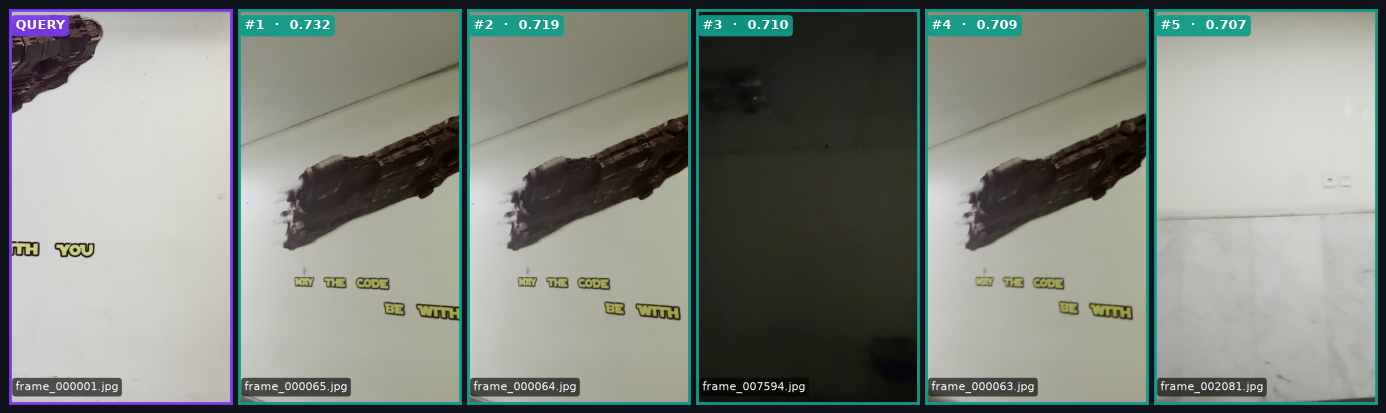

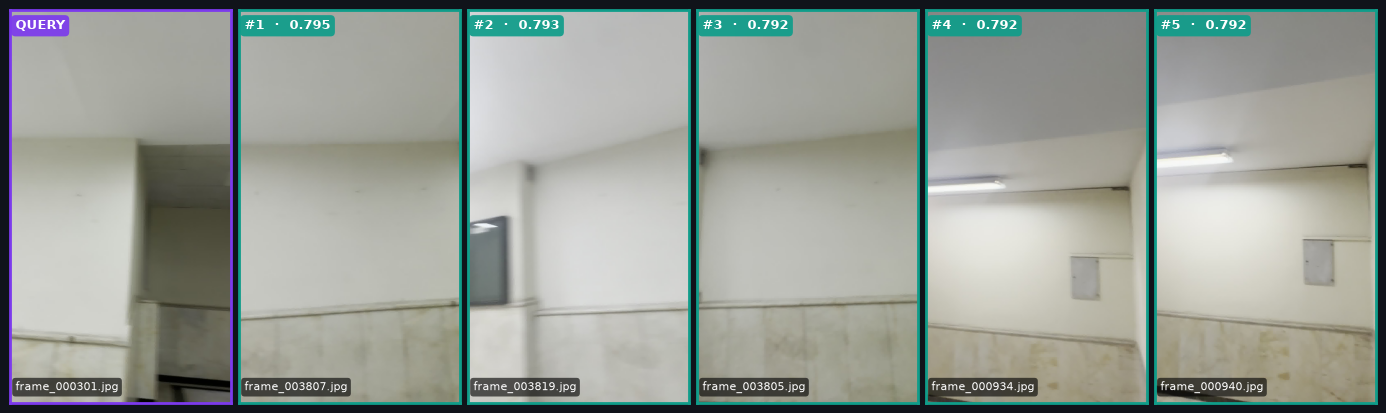

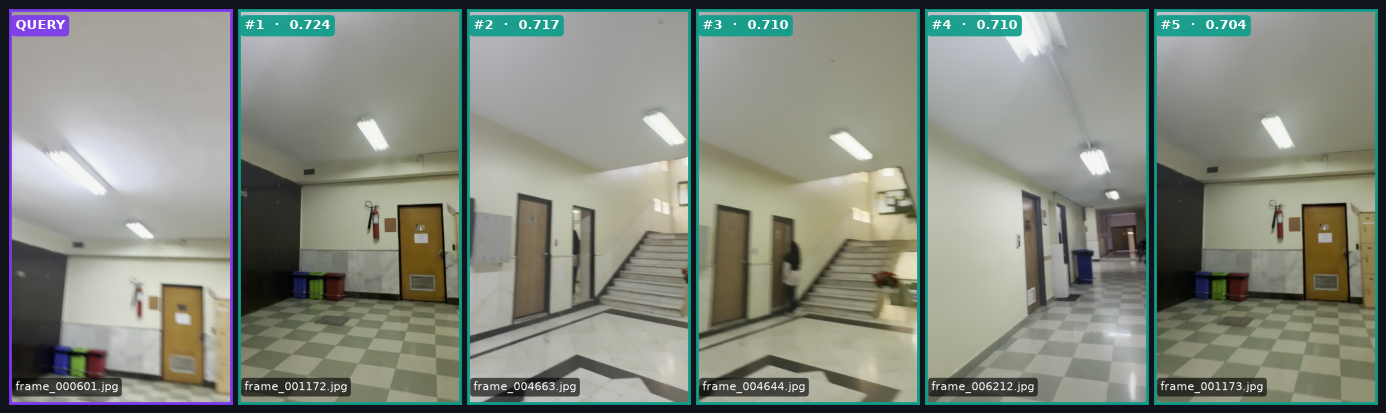

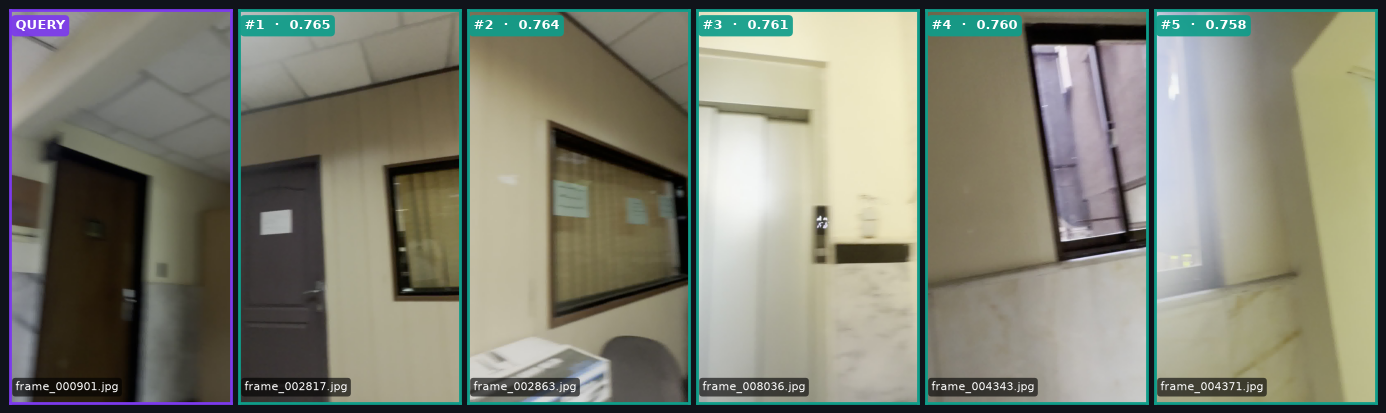

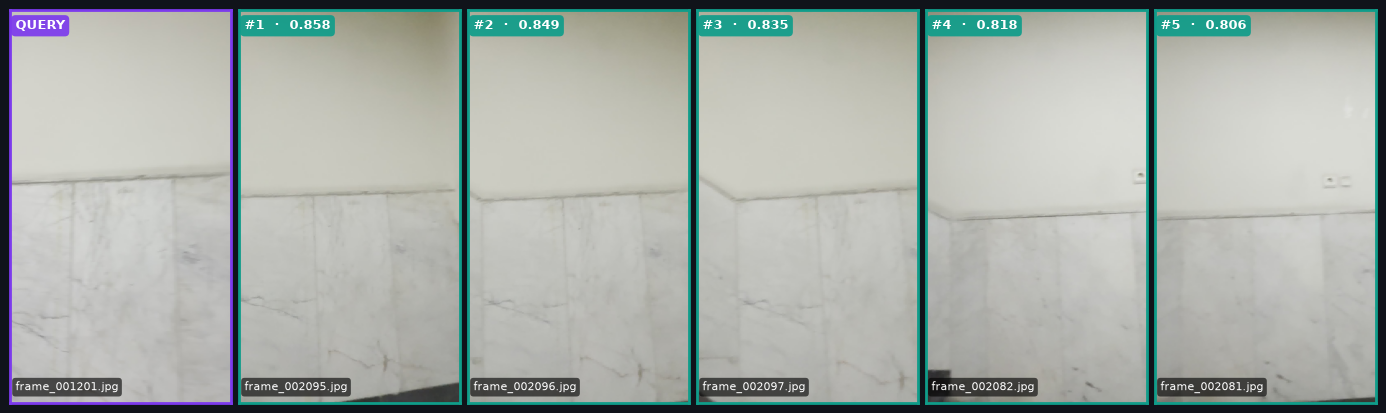

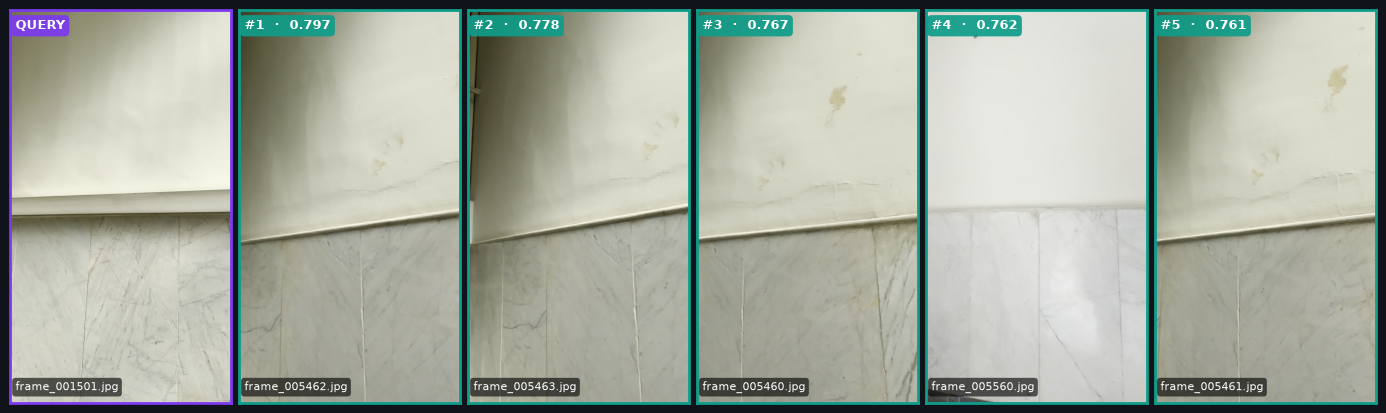

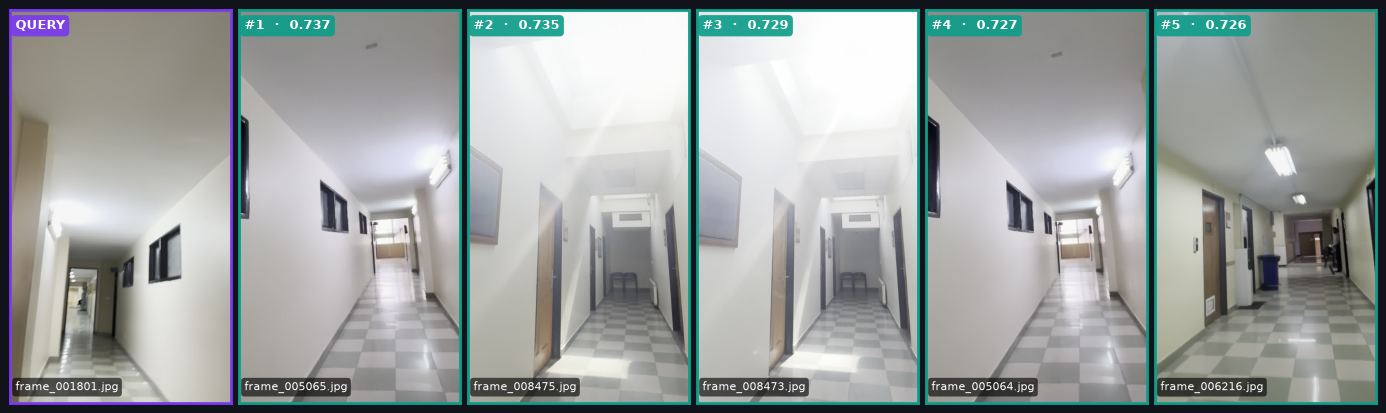

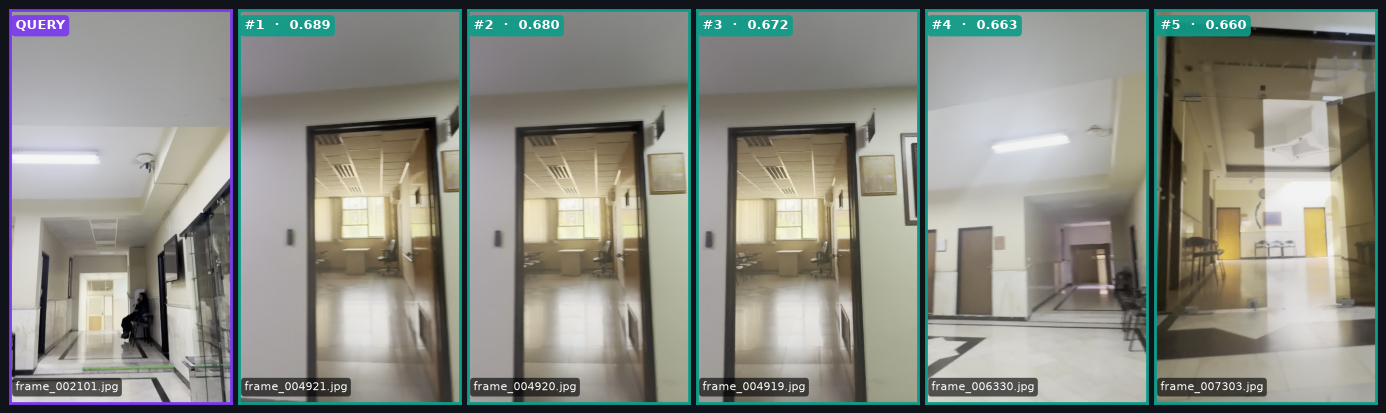

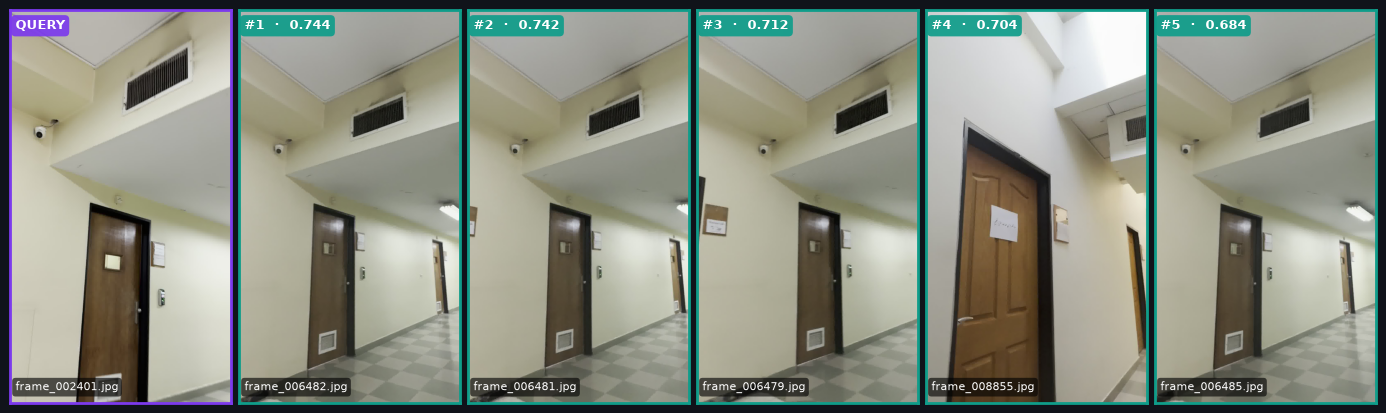

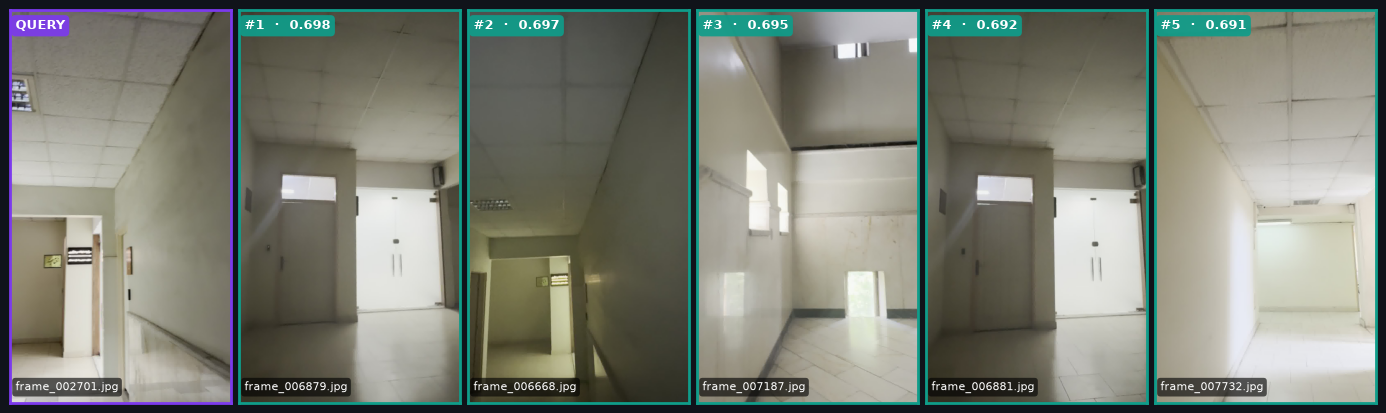

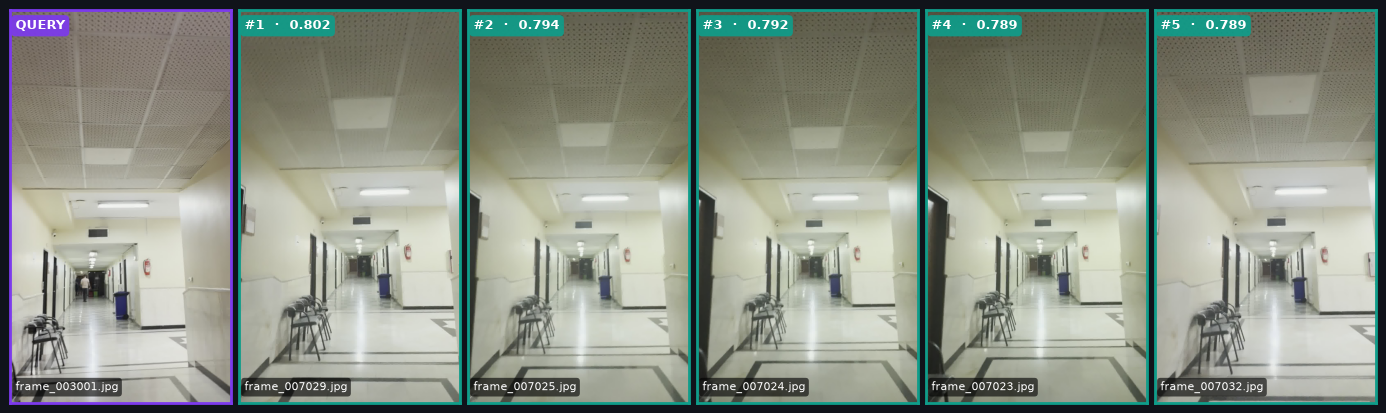

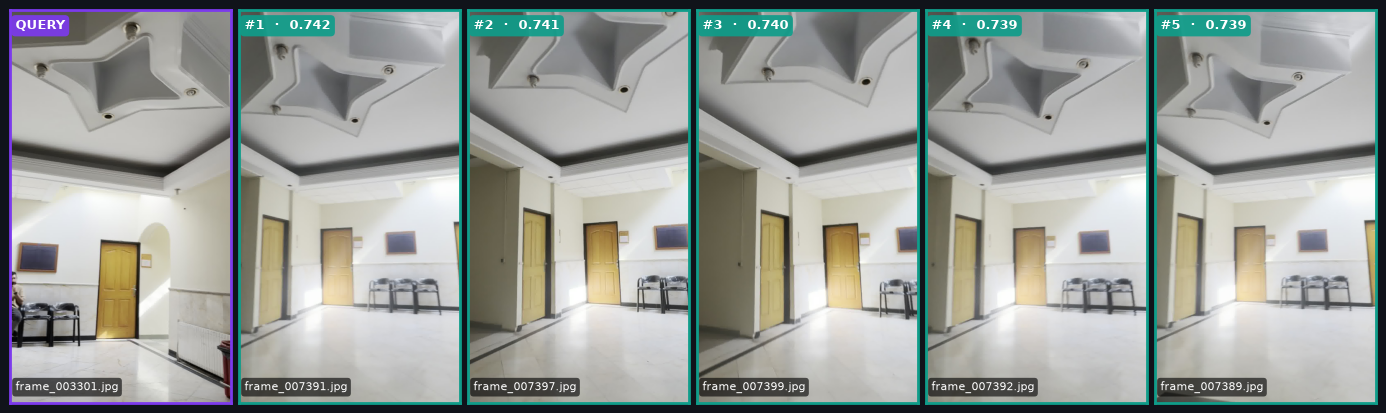

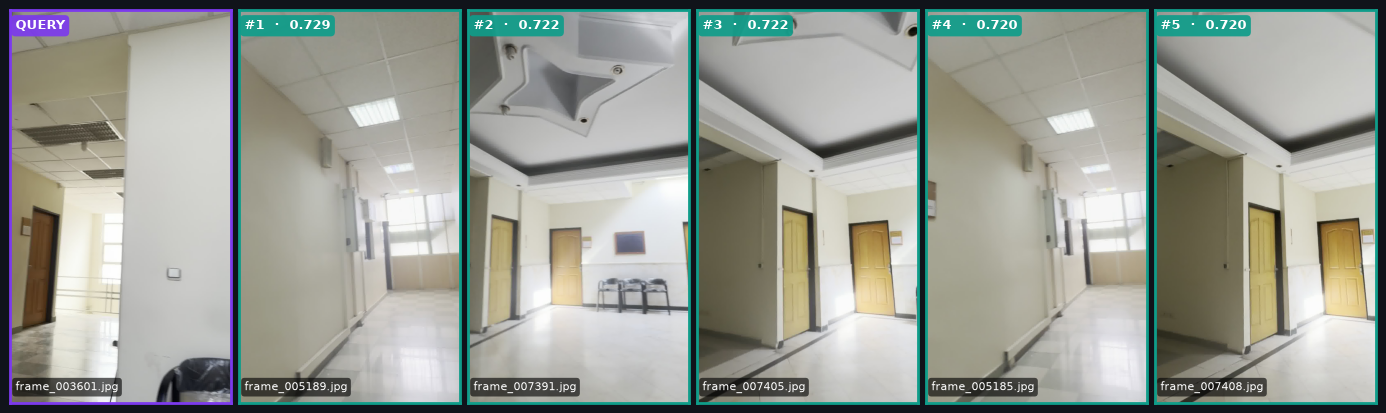

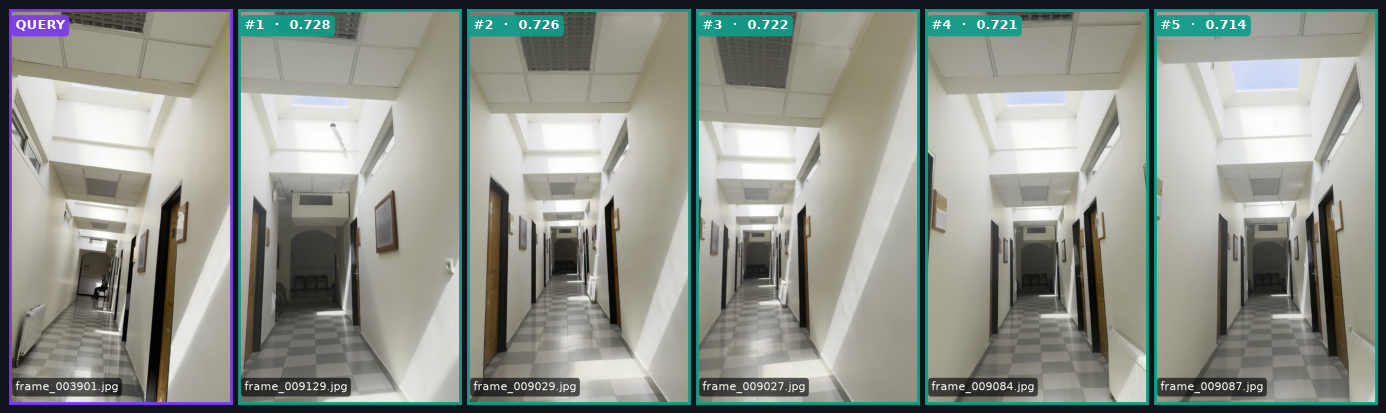

: 

In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from indoor_vpr import DatasetConfig, ImageDataset, SimilarityCSVView, StreamedVPRResults
from indoor_vpr.visualization import show_matches

# Choose which completed configuration to inspect.
INSPECT_CONFIGURATION = 'resnet18conv4_msls'  # Any key in NETVLAD_CONFIGURATIONS
ALGORITHM = 'netvlad'
DATASET_ROOT = PROJECT_ROOT / 'datasets' / 'dataset-2'
DATABASE_DIR = DATASET_ROOT / 'frames-IMG_3609'
QUERY_DIR = DATASET_ROOT / 'frames-IMG_3610'
MAX_DATABASE_IMAGES = None
MAX_QUERY_IMAGES = None
TOP_K = 5
SIMILARITY_CSV_PATH = PROJECT_ROOT / 'outputs'/ 'netvlad' / f'_netvlad_{INSPECT_CONFIGURATION}_similarity.csv'

dataset = ImageDataset.from_config(DatasetConfig(
    database_dir=DATABASE_DIR, query_dir=QUERY_DIR,
    max_database_images=MAX_DATABASE_IMAGES, max_query_images=MAX_QUERY_IMAGES,
))
if not SIMILARITY_CSV_PATH.is_file():
    raise FileNotFoundError(f'Similarity CSV not found: {SIMILARITY_CSV_PATH}')

similarity = SimilarityCSVView(
    SIMILARITY_CSV_PATH, len(dataset.query_paths), len(dataset.database_paths)
)
# The ranking is not retained here; SimilarityCSVView finds top matches lazily per row.
class CSVResults:
    def __init__(self, dataset, similarity):
        self.dataset = dataset
        self.similarity = similarity
    def top_indices(self, query_index, top_k=5):
        return self.similarity.top_indices(query_index, top_k)

inspect_results = CSVResults(dataset, similarity)
QUERY_INDEX = 5  # Change this to inspect another query.
for i in range(0, 4000, 300):
    show_matches(inspect_results, query_index=i, top_k=TOP_K)